In [15]:
import os
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

In [2]:
os.chdir('..')

In [6]:
CAR_SHARE_PATH = "data/filtered_block_groups/car_share.geojson"
BOUNDARIES_PATH = "data/lots/city_boundaries.geojson"

In [4]:
car_share = gpd.read_file(CAR_SHARE_PATH)

In [18]:
boundaries = gpd.read_file(BOUNDARIES_PATH)
boundaries.to_crs(epsg=5070, inplace=True)

In [19]:
car_share_cities = gpd.sjoin(car_share, boundaries, how='inner', predicate='intersects')

In [20]:
car_share_cities.head()

,geo_id,total_trips,car_trips,land_area,water_area,geometry,index_right,id
0,1500000US040131141001,1025.0,671.0,1309884,0,"POLYGON ((-1477964.783 1279049.196, -1477524.6...",74,phoenix-az
1,1500000US060750117001,222.0,0.0,58882,0,"POLYGON ((-2273903.153 1957521.268, -2273629.6...",88,san-francisco-ca
2,1500000US080310026031,746.0,242.0,154515,0,"POLYGON ((-762077.536 1894730.32, -761912.815 ...",27,denver-co
3,1500000US080410016002,1164.0,487.0,1055779,9954,"POLYGON ((-758252.613 1793440.502, -758025.711...",21,colorado-springs-co
4,1500000US091703614012,340.0,46.0,72671,0,"POLYGON ((1897480.148 2265173.773, 1897554.338...",64,new-haven-ct


In [21]:
car_share_cities["land_pct"] = car_share_cities["land_area"] / (car_share_cities["land_area"] + car_share_cities["water_area"])

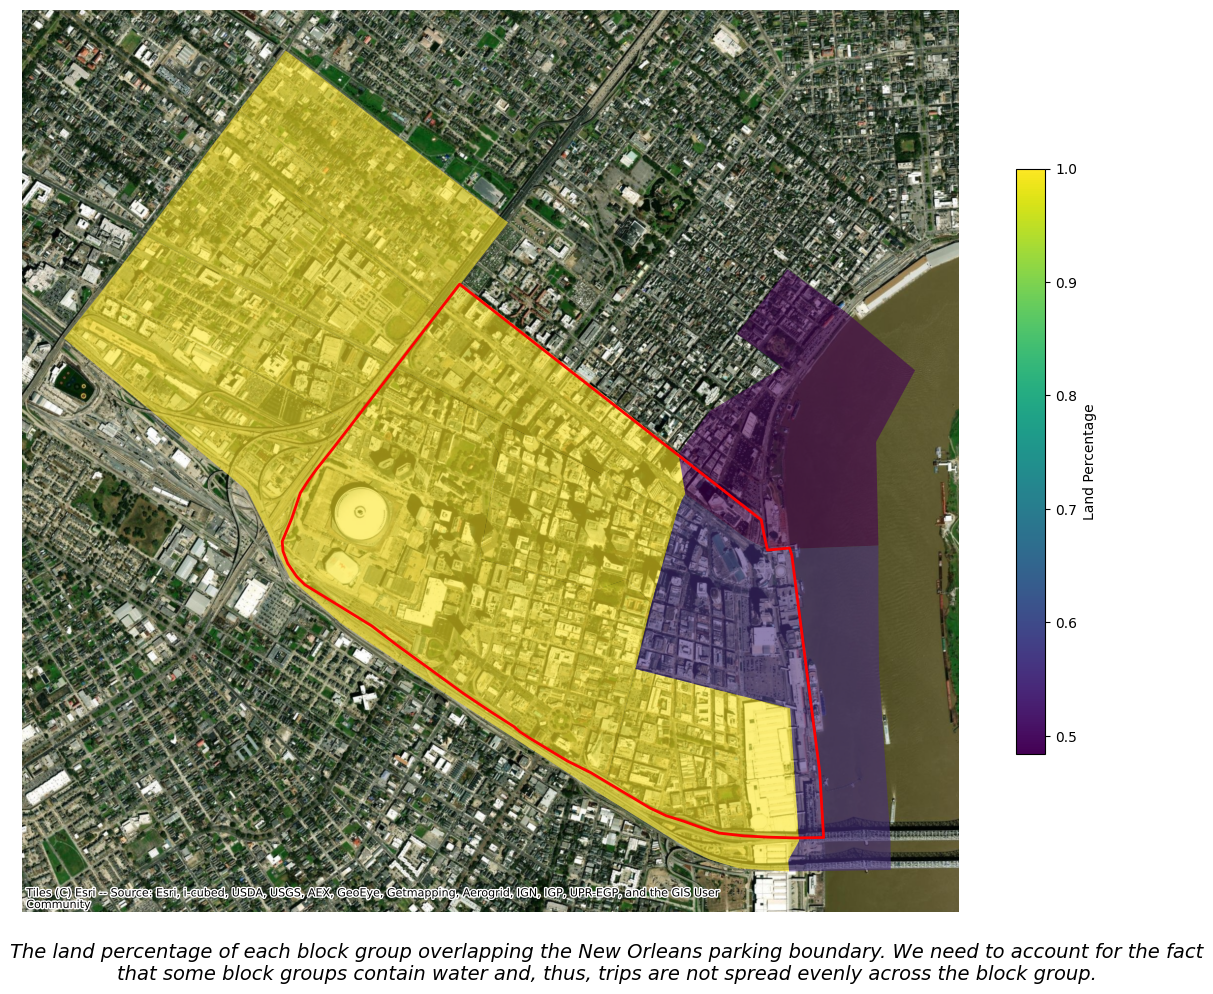

In [46]:
selected_city = "new-orleans-la"
water_example = car_share_cities[car_share_cities["id"] == selected_city]
boundary_city = boundaries[boundaries["id"] == selected_city]
water_example = water_example.to_crs(epsg=3857)
boundary_city = boundary_city.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))

water_example.plot(
    ax=ax,
    column="land_pct",
    cmap="viridis",
    alpha=0.6,
    legend=True,
    legend_kwds={
        "label": "Land Percentage",
        "shrink": 0.5,
        "orientation": "vertical"
    }
)

boundary_city.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2,
    facecolor="none",
    zorder=3
)

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    zoom=16
)

fig.text(
    0.5, 0.07, 
    "The land percentage of each block group overlapping the New Orleans parking boundary. We need to account for the fact that some block groups contain water and, thus, trips are not spread evenly across the block group.", 
    ha="center", 
    fontsize=14, 
    style='italic',
    wrap=True
)

ax.set_axis_off()
plt.tight_layout()